# Portfolio Construction & Risk Analytics Engine — Walkthrough

This notebook is a static, end-to-end walkthrough of the platform: it downloads a
multi-asset universe, estimates risk/return, builds an efficient frontier and three
named portfolios (Maximum Sharpe, Minimum Variance, Risk Parity), runs a Fama-French
factor decomposition, computes an institutional-style risk report (VaR/CVaR/drawdown/beta),
replays three historical stress windows plus a bootstrapped Monte Carlo simulation, backtests
buy-and-hold vs. quarterly rebalancing net of transaction costs, and exports a one-page PDF
"portfolio proposal."

**Disclaimer:** This notebook and the underlying platform are for **educational and research
purposes only**. Nothing here is investment advice, a recommendation, or an offer/solicitation
to buy or sell any security. Consult a licensed financial professional before making investment
decisions.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

from portfolio_risk_engine.config import (
    DEFAULT_UNIVERSE, DEFAULT_START_DATE, STRESS_TEST_START_DATE,
    BENCHMARK_TICKER, OptimizationConstraints,
)
from portfolio_risk_engine.data.loader import get_adjusted_close, align_and_clean, get_raw_daily_returns
from portfolio_risk_engine.estimators import compute_market_statistics, compute_daily_returns, CovarianceMethod
from portfolio_risk_engine.optimization.engine import (
    max_sharpe_portfolio, min_variance_portfolio, risk_parity_portfolio, efficient_frontier, risk_contributions,
)
from portfolio_risk_engine.factor.fama_french import download_fama_french_factors, run_factor_regression, factor_regression_table
from portfolio_risk_engine.risk.metrics import build_risk_report
from portfolio_risk_engine.risk.stress import portfolio_daily_returns, run_stress_tests, run_monte_carlo
from portfolio_risk_engine.backtest.rebalance import compare_buy_and_hold_vs_rebalanced
from portfolio_risk_engine.reporting.pdf_report import generate_portfolio_proposal_pdf

RISK_FREE_RATE = 0.03


## 1. Data: multi-asset universe

We pull adjusted daily close prices for an 18-asset universe spanning US equity,
international equity, bonds, REITs, and commodities, going back to 2013 (13+ years).
Prices are cached locally (parquet/CSV) so re-running this notebook doesn't re-hit the
network unless the cache is missing or stale.


In [2]:
tickers = list(DEFAULT_UNIVERSE.keys())
raw_prices = get_adjusted_close(tickers + [BENCHMARK_TICKER], start=DEFAULT_START_DATE)
prices = align_and_clean(raw_prices)
print(f"{len(prices.columns)} assets, {prices.index.min().date()} to {prices.index.max().date()} ({len(prices)} trading days)")
prices.tail()


18 assets, 2013-06-04 to 2026-07-06 (3291 trading days)


,AGG,BNDX,DBC,EFA,EWJ,GLD,HYG,IEF,IWM,LQD,QQQ,RWX,SPY,TLT,VGK,VNQ,VTV,VWO
Date,,,,,,,,,,,,,,,,,,
2026-06-29,99.037697,48.408794,26.559999,103.449997,93.209999,368.579987,79.640816,94.747383,298.970001,109.315796,724.080017,27.190001,741.000000,87.128204,88.070000,98.150002,218.630005,59.180000
2026-06-30,98.649002,48.319000,26.660000,103.879997,93.269997,368.380005,79.600998,94.259003,300.450012,108.688004,736.400024,27.010000,746.770020,86.101997,88.540001,96.430000,217.929993,59.689999
2026-07-01,98.500000,48.270000,26.450001,103.019997,93.050003,370.600006,79.589996,94.029999,299.320007,108.459999,725.169983,26.900000,745.760010,85.519997,87.769997,96.820000,217.380005,59.220001
2026-07-02,98.610001,48.240002,26.570000,104.370003,93.139999,378.130005,79.709999,94.120003,297.579987,108.639999,712.599976,27.309999,744.780029,85.510002,89.349998,98.019997,219.169998,59.040001
2026-07-06,98.660004,48.220001,27.000000,105.459999,95.269997,382.130005,79.870003,94.180000,298.899994,108.669998,722.820007,27.340000,751.280029,85.449997,89.970001,97.239998,219.440002,60.070000


## 2. Return & risk estimation

Two covariance estimators are supported:

- **Sample covariance** — the textbook maximum-likelihood estimate. With N assets and T
  daily observations, it's unbiased but noisy: estimation error concentrates in the
  extreme eigenvalues, which is exactly what a mean-variance optimizer will overfit to,
  producing concentrated, unstable "optimal" portfolios that don't hold up out-of-sample.
- **Ledoit-Wolf shrinkage** — shrinks the sample covariance toward a structured target
  (a scaled identity matrix), with the shrinkage intensity chosen automatically to minimize
  expected estimation error (Ledoit & Wolf, 2004). This trades a small amount of bias for a
  large reduction in variance, typically producing more diversified, stable portfolios.

We use Ledoit-Wolf as the default throughout this notebook.


In [3]:
asset_prices = prices[tickers]
stats_sample = compute_market_statistics(asset_prices, method=CovarianceMethod.SAMPLE)
stats_lw = compute_market_statistics(asset_prices, method=CovarianceMethod.LEDOIT_WOLF)
print(f"Ledoit-Wolf shrinkage intensity: {stats_lw.shrinkage_intensity:.3f} (0 = pure sample, 1 = pure structured target)")

comparison = pd.DataFrame({
    "Annualized Return": stats_lw.mean_returns,
    "Annualized Vol (Sample)": np.sqrt(np.diag(stats_sample.cov_matrix)),
    "Annualized Vol (Ledoit-Wolf)": np.sqrt(np.diag(stats_lw.cov_matrix)),
}).sort_values("Annualized Return", ascending=False)
comparison


Ledoit-Wolf shrinkage intensity: 0.008 (0 = pure sample, 1 = pure structured target)


,Annualized Return,Annualized Vol (Sample),Annualized Vol (Ledoit-Wolf)
QQQ,0.206311,0.210780,0.210382
SPY,0.148593,0.169890,0.169763
VTV,0.126906,0.159094,0.159047
IWM,0.122514,0.217015,0.216579
VGK,0.093594,0.183068,0.182848
EWJ,0.093416,0.177012,0.176834
GLD,0.092809,0.162441,0.162369
EFA,0.087655,0.168208,0.168094
VNQ,0.084940,0.196204,0.195898
VWO,0.075936,0.194646,0.194350


## 3. Optimization: three named portfolios + the efficient frontier

- **Minimum Variance** — the single portfolio with the lowest possible volatility.
- **Maximum Sharpe Ratio** (tangency portfolio) — the portfolio maximizing excess return
  per unit of volatility, solved as a convex QP via the standard Cornuejols-Tutuncu
  change of variables.
- **Risk Parity (Equal Risk Contribution)** — each asset contributes equally to total
  portfolio risk, rather than equally to capital. This avoids the common failure mode
  where a "diversified" cap-weighted or equal-weighted portfolio is secretly dominated
  by equity risk.

All three respect a long-only, max-35%-per-asset constraint by default (configurable).


In [4]:
constraints = OptimizationConstraints(long_only=True, max_weight=0.35)

portfolios = {
    "Maximum Sharpe Ratio": max_sharpe_portfolio(stats_lw.mean_returns, stats_lw.cov_matrix, constraints, RISK_FREE_RATE),
    "Minimum Variance": min_variance_portfolio(stats_lw.mean_returns, stats_lw.cov_matrix, constraints, RISK_FREE_RATE),
    "Risk Parity": risk_parity_portfolio(stats_lw.mean_returns, stats_lw.cov_matrix, constraints, RISK_FREE_RATE),
}

summary = pd.DataFrame([
    {"Portfolio": name, "Expected Return": p.expected_return, "Volatility": p.volatility, "Sharpe Ratio": p.sharpe_ratio}
    for name, p in portfolios.items()
]).set_index("Portfolio")
summary.style.format({"Expected Return": "{:.2%}", "Volatility": "{:.2%}", "Sharpe Ratio": "{:.2f}"})


,Expected Return,Volatility,Sharpe Ratio
Portfolio,,,
Maximum Sharpe Ratio,14.27%,12.99%,0.87
Minimum Variance,2.58%,4.17%,-0.10
Risk Parity,5.11%,6.64%,0.32


Frontier resolution: 50 points


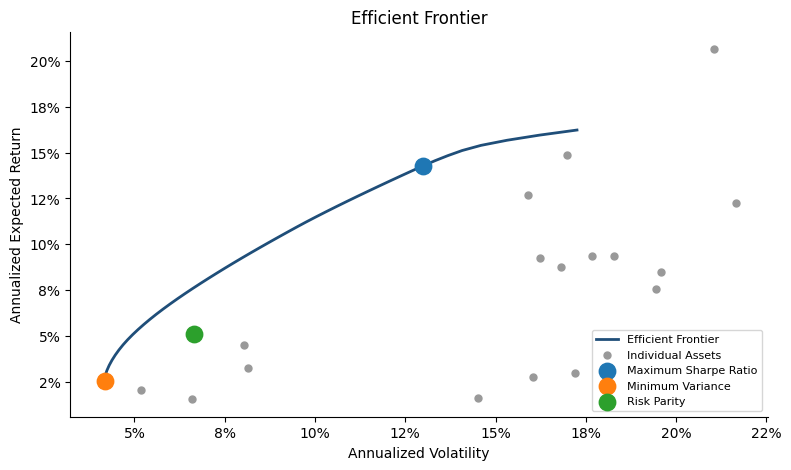

In [5]:
frontier = efficient_frontier(stats_lw.mean_returns, stats_lw.cov_matrix, constraints, n_points=50, risk_free_rate=RISK_FREE_RATE)
print(f"Frontier resolution: {len(frontier)} points")

fig, ax = plt.subplots()
ax.plot(frontier["volatility"], frontier["target_return"], color="#1f4e79", lw=2, label="Efficient Frontier")
asset_vol = np.sqrt(np.diag(stats_lw.cov_matrix))
ax.scatter(asset_vol, stats_lw.mean_returns, color="#999", s=25, label="Individual Assets", zorder=3)
for name, p in portfolios.items():
    ax.scatter([p.volatility], [p.expected_return], s=140, zorder=5, label=name)
ax.set_xlabel("Annualized Volatility"); ax.set_ylabel("Annualized Expected Return")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(loc="lower right", fontsize=8)
ax.set_title("Efficient Frontier")
plt.show()


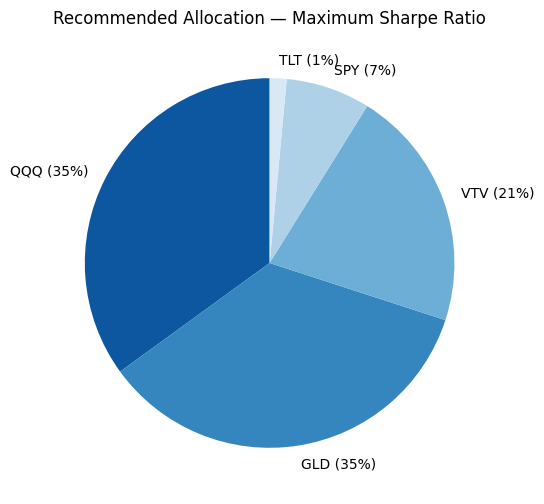

Risk Parity fractional risk contributions (should be ~equal):
[0.056 0.056 0.056 0.056 0.056 0.056 0.056 0.056 0.056 0.056 0.056 0.056
 0.056 0.056 0.056 0.056 0.056 0.056]


In [6]:
recommended_name = "Maximum Sharpe Ratio"
recommended = portfolios[recommended_name]

w = recommended.weights[recommended.weights > 1e-4].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(w.values, labels=[f"{t} ({w[t]:.0%})" for t in w.index], startangle=90,
       colors=plt.cm.Blues_r(np.linspace(0.15, 0.85, len(w))))
ax.set_title(f"Recommended Allocation — {recommended_name}")
plt.show()

# Sanity check: risk parity should equalize each asset's fractional contribution to portfolio risk.
rp = portfolios["Risk Parity"]
rc = risk_contributions(rp.weights.values, stats_lw.cov_matrix)
print("Risk Parity fractional risk contributions (should be ~equal):")
print((rc / rc.sum()).round(3))


## 4. Factor analysis: Fama-French 3-factor regression

Each asset's (and the recommended portfolio's) excess daily return is regressed on the
Fama-French market, size (SMB), and value (HML) factors, downloaded from Ken French's
data library:

`excess_return = alpha + β_mkt·(Mkt-RF) + β_smb·SMB + β_hml·HML + ε`

`alpha` (annualized) is the return left unexplained by factor exposures; R² is the
fraction of return variance the three factors explain.


In [7]:
asset_returns = compute_daily_returns(asset_prices)
factors = download_fama_french_factors("3F")

factor_results = run_factor_regression(asset_returns, factors, model="3F")
factor_table = factor_regression_table(factor_results)

port_returns_series = portfolio_daily_returns(asset_returns, recommended.weights).to_frame(name=recommended_name)
port_factor_result = run_factor_regression(port_returns_series, factors, model="3F")
factor_table = pd.concat([factor_table, factor_regression_table(port_factor_result)])

factor_table.style.format({"Annualized Alpha": "{:.2%}", "Mkt-RF": "{:.2f}", "SMB": "{:.2f}", "HML": "{:.2f}", "R-squared": "{:.1%}"})


,Annualized Alpha,Mkt-RF,SMB,HML,R-squared
Asset,,,,,
SPY,0.01%,0.98,-0.12,0.02,99.4%
IWM,-1.34%,1.01,0.87,0.24,97.9%
QQQ,3.79%,1.11,-0.12,-0.40,94.3%
VTV,-0.67%,0.87,-0.10,0.37,93.7%
EFA,-3.82%,0.82,0.01,0.15,72.6%
VWO,-5.06%,0.83,0.02,0.05,55.5%
VGK,-3.72%,0.86,0.02,0.18,67.5%
EWJ,-2.18%,0.73,0.02,0.09,52.7%
AGG,0.10%,0.02,0.05,-0.05,3.7%


## 5. Risk report: VaR, CVaR, drawdown, downside deviation, beta

- **VaR (Value at Risk)** at 95%/99% is the historical (empirical) loss threshold: a 95%
  daily VaR of 1.5% means there's a 5% chance of losing 1.5% or more on any given day,
  based on the realized return distribution (no normality assumption).
- **CVaR (Conditional VaR / Expected Shortfall)** is the *average* loss in the tail beyond
  the VaR threshold — it answers "given that we blew through VaR, how bad was it?" and is
  always at least as large as VaR.
- **Max drawdown** is the worst peak-to-trough decline in cumulative wealth.
- **Downside deviation** is volatility computed only over losing days (Sortino's risk measure).


In [8]:
benchmark_returns = compute_daily_returns(prices[[BENCHMARK_TICKER]])[BENCHMARK_TICKER]
port_returns = portfolio_daily_returns(asset_returns, recommended.weights)
report = build_risk_report(port_returns, risk_free_rate=RISK_FREE_RATE, benchmark_returns=benchmark_returns)

pd.Series({
    "Annualized Return": f"{report.annualized_return:.2%}",
    "Annualized Volatility": f"{report.annualized_volatility:.2%}",
    "Sharpe Ratio": f"{report.sharpe_ratio:.2f}",
    "Sortino Ratio": f"{report.sortino_ratio:.2f}",
    f"Beta vs. {BENCHMARK_TICKER}": f"{report.beta:.2f}",
    "Max Drawdown": f"{report.max_drawdown:.2%} ({report.max_drawdown_peak.date()} -> {report.max_drawdown_trough.date()})",
    "95% Daily VaR / CVaR": f"{report.var_95:.2%} / {report.cvar_95:.2%}",
    "99% Daily VaR / CVaR": f"{report.var_99:.2%} / {report.cvar_99:.2%}",
    "Downside Deviation": f"{report.downside_deviation:.2%}",
}, name="Value").to_frame()


,Value
Annualized Return,14.36%
Annualized Volatility,13.02%
Sharpe Ratio,0.87
Sortino Ratio,1.24
Beta vs. SPY,0.68
Max Drawdown,22.00% (2020-02-19 -> 2020-03-20)
95% Daily VaR / CVaR,1.20% / 1.92%
99% Daily VaR / CVaR,2.33% / 3.25%
Downside Deviation,9.09%


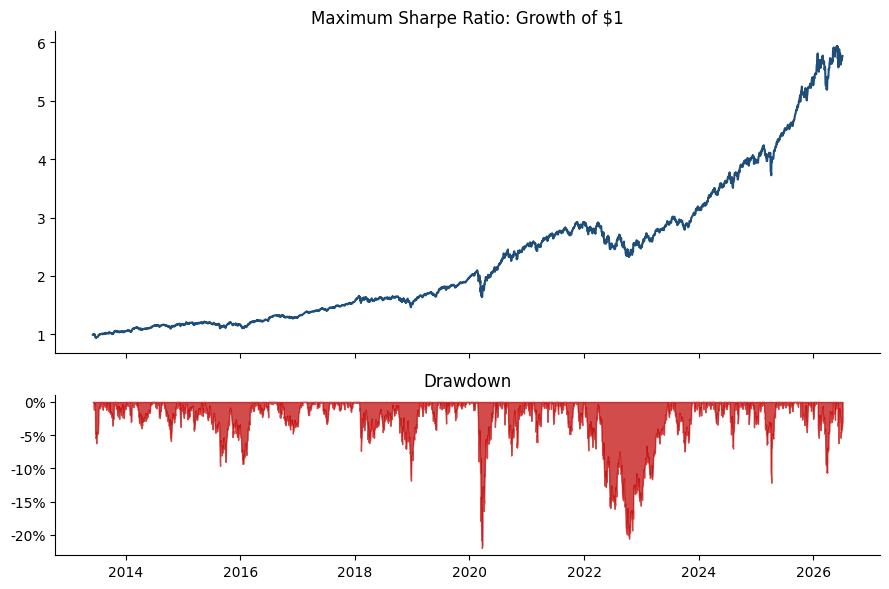

In [9]:
cumulative = (1 + port_returns).cumprod()
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 6), gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(cumulative.index, cumulative.values, color="#1f4e79")
axes[0].set_title(f"{recommended_name}: Growth of $1")
running_max = cumulative.cummax()
drawdown = cumulative / running_max - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0, color="#c00000", alpha=0.7)
axes[1].set_title("Drawdown")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.show()


## 6. Stress testing: 2008 GFC, March 2020 COVID crash, 2022 rate-hike drawdown

Historical windows are replayed using an *extended* price history (back to 2005) so the
2008 crisis is covered even though one universe ETF (BNDX) didn't launch until 2013 — for
that specific window, BNDX is excluded and the remaining target weights are rescaled to
sum to 1, with the exclusion reported explicitly rather than silently distorting results.


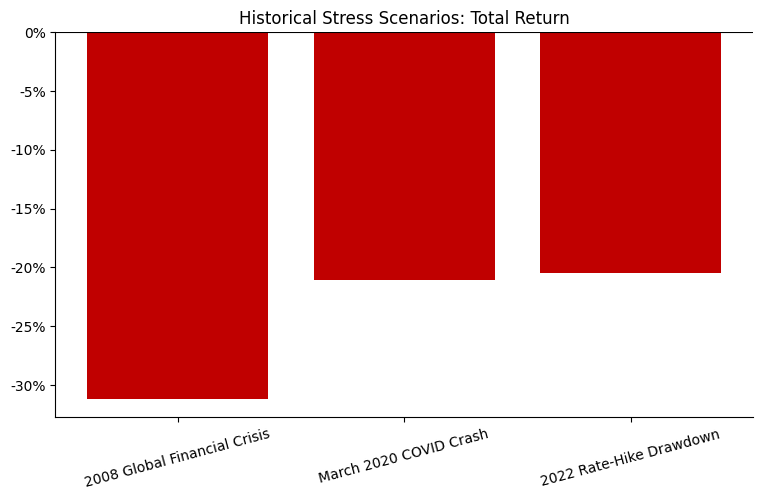

,Start,End,Total Return,Max Drawdown,Excluded Assets
Window,,,,,
2008 Global Financial Crisis,2007-10-09,2009-03-09,-31.18%,36.86%,BNDX
March 2020 COVID Crash,2020-02-19,2020-03-23,-21.05%,22.00%,—
2022 Rate-Hike Drawdown,2022-01-03,2022-10-14,-20.49%,20.43%,—


In [10]:
stress_returns = get_raw_daily_returns(tickers, start=STRESS_TEST_START_DATE)
stress_results = run_stress_tests(stress_returns, recommended.weights)

stress_df = pd.DataFrame([{
    "Window": r.window_name, "Start": r.start, "End": r.end,
    "Total Return": r.total_return, "Max Drawdown": r.max_drawdown,
    "Excluded Assets": ", ".join(r.excluded_assets) or "—",
} for r in stress_results]).set_index("Window")

fig, ax = plt.subplots()
colors = ["#c00000" if v < 0 else "#548235" for v in stress_df["Total Return"]]
ax.bar(stress_df.index, stress_df["Total Return"], color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Historical Stress Scenarios: Total Return")
plt.xticks(rotation=15)
plt.show()

stress_df.style.format({"Total Return": "{:.2%}", "Max Drawdown": "{:.2%}"})


## 7. Monte Carlo simulation (10,000 bootstrapped paths)

Daily portfolio returns are resampled using a **block bootstrap** (contiguous 20-day
chunks, not single i.i.d. days) to partially preserve volatility clustering, then
compounded out to 1-year and 5-year horizons.


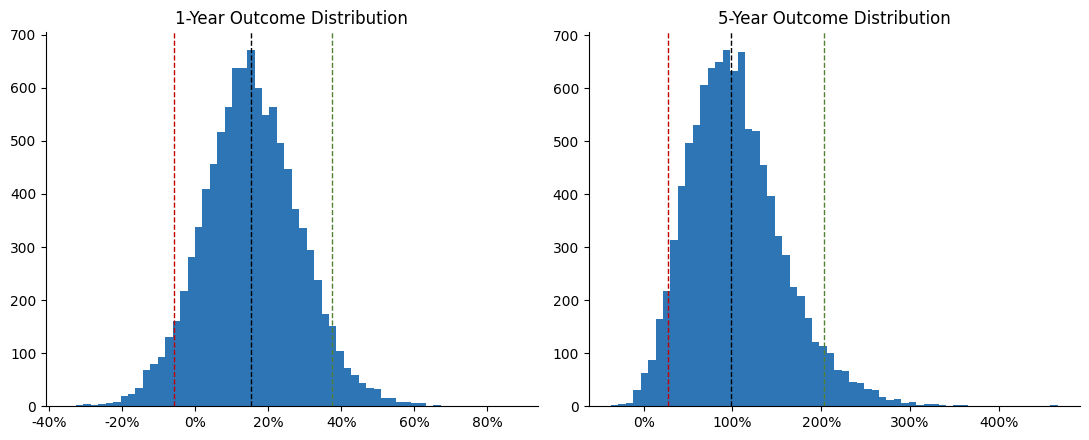

,Median,Mean,5th pct,95th pct,Prob. of Loss
1,15.1%,15.5%,-6.0%,37.5%,11.5%
5,98.5%,104.4%,27.3%,203.2%,0.7%


In [11]:
mc_results = run_monte_carlo(port_returns, horizons_years=(1, 5), n_paths=10_000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (horizon, res) in zip(axes, mc_results.items()):
    ax.hist(res.paths, bins=60, color="#2e75b6")
    for val, label, color in [(res.percentile_5, "5th pct", "#c00000"), (res.median, "Median", "black"), (res.percentile_95, "95th pct", "#548235")]:
        ax.axvline(val, color=color, linestyle="--", linewidth=1)
    ax.set_title(f"{horizon}-Year Outcome Distribution")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.show()

pd.DataFrame({h: {"Median": r.median, "Mean": r.mean, "5th pct": r.percentile_5, "95th pct": r.percentile_95, "Prob. of Loss": r.prob_of_loss}
              for h, r in mc_results.items()}).T.style.format("{:.1%}")


## 8. Rebalancing backtest: buy-and-hold vs. quarterly, net of costs

Both variants start at the same target weights. Buy-and-hold lets weights drift with
relative performance; the rebalanced version trades back to target every quarter, paying
a configurable transaction cost (10 bps/trade here) on turnover each time.


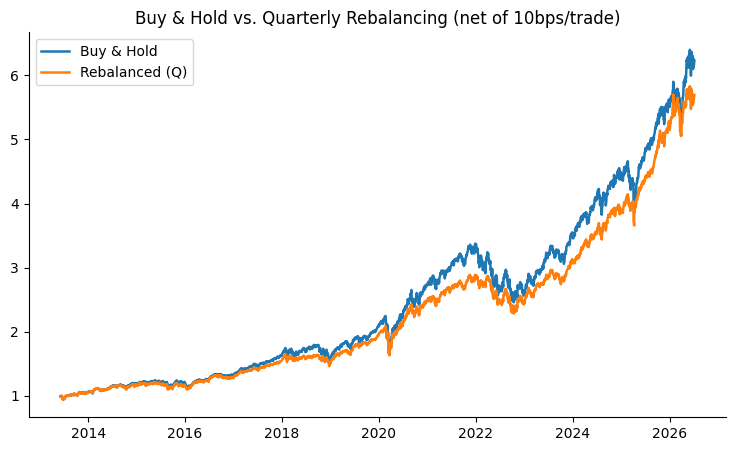

,CAGR,Volatility,Sharpe,Max Drawdown,Txn Cost Drag,# Rebalances
Strategy,,,,,,
Buy & Hold,15.04%,15.55%,0.77,27.13%,0.100%,0
Rebalanced (Q),14.24%,12.88%,0.87,21.78%,0.335%,54


In [12]:
bt = compare_buy_and_hold_vs_rebalanced(asset_returns, recommended.weights, rebalance_freq="Q", cost_bps=10.0, risk_free_rate=RISK_FREE_RATE)

fig, ax = plt.subplots()
for r in bt.values():
    ax.plot(r.portfolio_value.index, r.portfolio_value.values, label=r.label, lw=1.8)
ax.set_title("Buy & Hold vs. Quarterly Rebalancing (net of 10bps/trade)")
ax.legend()
plt.show()

pd.DataFrame([{
    "Strategy": r.label, "CAGR": r.cagr, "Volatility": r.annualized_volatility,
    "Sharpe": r.sharpe_ratio, "Max Drawdown": r.max_drawdown,
    "Txn Cost Drag": r.total_transaction_costs, "# Rebalances": r.n_rebalances,
} for r in bt.values()]).set_index("Strategy").style.format({
    "CAGR": "{:.2%}", "Volatility": "{:.2%}", "Sharpe": "{:.2f}", "Max Drawdown": "{:.2%}", "Txn Cost Drag": "{:.3%}",
})


## 9. Export: one-page PDF portfolio proposal

The same recommended portfolio, risk report, frontier, and stress results feed a single
`generate_portfolio_proposal_pdf(...)` call that produces a client-ready, one-page PDF —
the kind of document an advisor would hand across the table.


In [13]:
out_path = Path.cwd().parent / "outputs" / "sample_proposal.pdf"
out_path.parent.mkdir(exist_ok=True)
generate_portfolio_proposal_pdf(
    str(out_path), recommended_name, recommended.weights, report, DEFAULT_UNIVERSE,
    frontier=frontier, current_point={"volatility": recommended.volatility, "expected_return": recommended.expected_return},
    stress_results=stress_results, benchmark_name=BENCHMARK_TICKER, risk_free_rate=RISK_FREE_RATE,
)
print(f"Saved: {out_path.relative_to(Path.cwd().parent)}")


Saved: outputs/sample_proposal.pdf


## Summary

This walkthrough covered the full pipeline the Streamlit app exposes interactively:
data → risk estimation (sample vs. Ledoit-Wolf shrinkage) → optimization (max Sharpe,
min variance, risk parity, efficient frontier) → factor analysis → risk report →
stress testing → Monte Carlo simulation → rebalancing backtest → PDF export.

**Reminder:** educational/research tool only — not investment advice.
